# Theme 9: 단순 및 다중 회귀 모델 실습 (2026-04-27)

## 1. 실습 목표
- 수치 데이터를 예측하는 **회귀 모델(Regression)**의 원리를 이해합니다.
- **단순 회귀(Simple Linear Regression)**와 **다중 회귀(Multiple Linear Regression)**를 실습합니다.
- 모델의 성능을 다양한 지표(**MAE, MSE, RMSE, R-Squared**)로 평가하고 해석합니다.

## 2. 라이브러리 및 데이터 로드

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows용 한글 폰트
# plt.rcParams['font.family'] = 'AppleGothic' # Mac용 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

In [24]:
data_path = './content/boston.csv'
df = pd.read_csv(data_path)
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


## 3. 데이터 탐색 (EDA) 및 변수 선택

- 타겟 변수: `medv` (주택 가격 중앙값)
- 상관관계 분석을 통해 주요 독립 변수를 확인합니다.

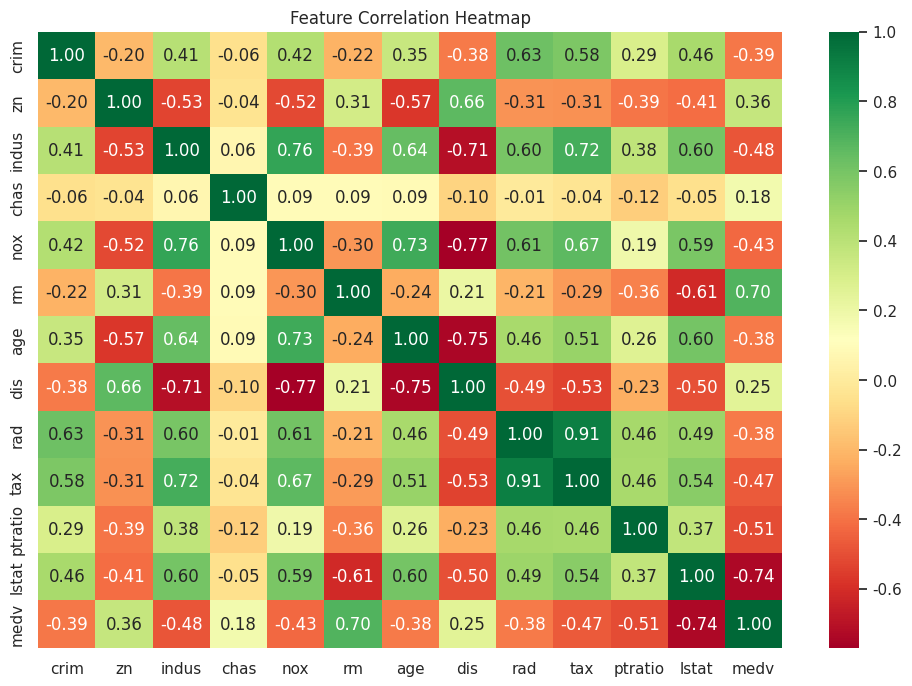

In [25]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## 4. 데이터 분할 (Train/Test Split)

- 데이터 누수를 방지하기 위해 학습용과 평가용 데이터를 분리합니다.

In [26]:
target = 'medv'
x = df.drop(target, axis=1)
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

print(f"Train set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

Train set shape: (354, 12)
Test set shape: (152, 12)


## 5. 모델링: 단순 회귀 (Simple Linear Regression)

- 상관관계가 가장 높았던 `lstat` 변수 하나만 사용하여 예측해봅니다.

In [27]:
feature_simple = ['lstat']
x_train_s = x_train[feature_simple]
x_test_s = x_test[feature_simple]

model_s = LinearRegression()
model_s.fit(x_train_s, y_train)

y_pred_s = model_s.predict(x_test_s)

print(f"Coefficients: {model_s.coef_}")
print(f"Intercept: {model_s.intercept_}")

Coefficients: [-0.9166916]
Intercept: 34.22183685037717


## 6. 모델링: 다중 회귀 (Multiple Linear Regression)

- 모든 변수를 사용하여 성능을 향상시킵니다.

In [28]:
model_m = LinearRegression()
model_m.fit(x_train, y_train)

y_pred_m = model_m.predict(x_test)

print(f"Coefficients: {model_m.coef_}")
print(f"Intercept: {model_m.intercept_}")

Coefficients: [-1.13844848e-01  6.11702680e-02  5.41034650e-02  2.51751196e+00
 -2.22485023e+01  2.69841282e+00  4.83604728e-03 -1.53429538e+00
  2.98833255e-01 -1.14135806e-02 -9.88914626e-01 -5.86132851e-01]
Intercept: 49.885234663817236


## 7. 성능 평가 및 비교

- MAE, MSE, RMSE, R-Squared를 계산합니다.

In [29]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"[{model_name} Results]")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}")
    print("-" * 30)

evaluate_model(y_test, y_pred_s, "Simple Regression")
evaluate_model(y_test, y_pred_m, "Multiple Regression")

[Simple Regression Results]
MAE: 4.82
MSE: 42.62
RMSE: 6.53
R2 Score: 0.5350
------------------------------
[Multiple Regression Results]
MAE: 3.44
MSE: 20.88
RMSE: 4.57
R2 Score: 0.7722
------------------------------


## 8. 결과 시각화

- 실제값 vs 예측값 산점도를 그려 모델의 예측 성능을 시각적으로 확인합니다.

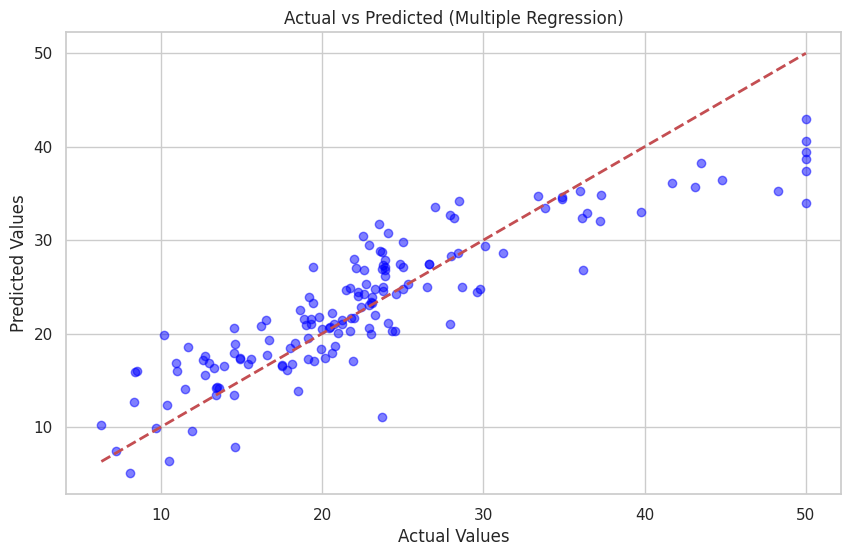

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_m, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted (Multiple Regression)')
plt.show()

Train set shape: (107, 3)
Test set shape: (46, 3)
Coefficients: [ 0.05441708 -2.84469739  1.47537877]
Intercept: -57.967472113341
[Multiple Regression Results]
MAE: 18.49
MSE: 571.52
RMSE: 23.91
MAPE: 0.70
R2 Score: 0.4361
------------------------------


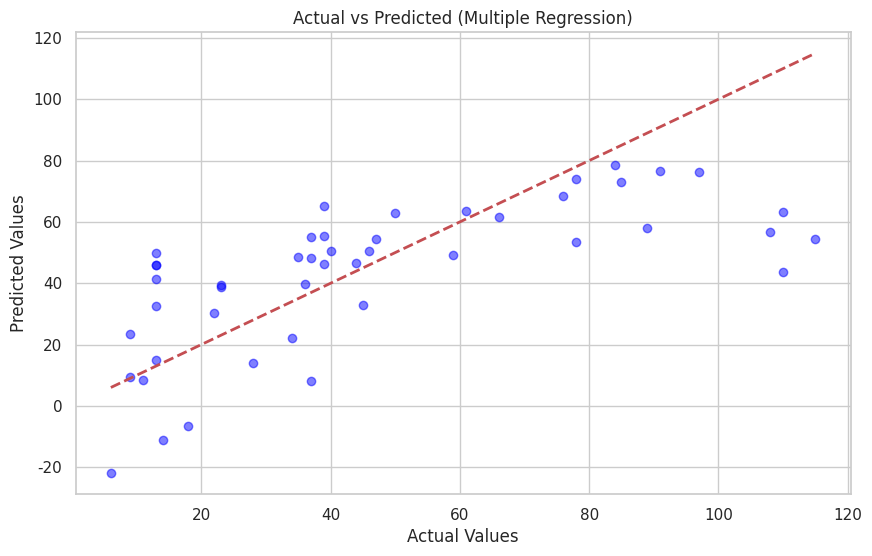

In [39]:
df = pd.read_csv('content/airquality.csv')

df.ffill(inplace=True)
df.drop(['Month', 'Day'], axis=1, inplace=True)

target = 'Ozone'
x = df.drop(target, axis=1)
y = df[target]

def linear(x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

    print(f"Train set shape: {x_train.shape}")
    print(f"Test set shape: {x_test.shape}")

    model_m = LinearRegression()
    model_m.fit(x_train, y_train)

    y_pred_m = model_m.predict(x_test)

    print(f"Coefficients: {model_m.coef_}")
    print(f"Intercept: {model_m.intercept_}")

    def evaluate_model(y_true, y_pred, model_name):
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        print(f"[{model_name} Results]")
        print(f"MAE: {mae:.2f}")
        print(f"MSE: {mse:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"MAPE: {mape:.2f}")
        print(f"R2 Score: {r2:.4f}")
        print("-" * 30)

    evaluate_model(y_test, y_pred_m, "Multiple Regression")

    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred_m, alpha=0.5, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted (Multiple Regression)')
    plt.show()

linear(x,y)

Train set shape: (348, 1)
Test set shape: (150, 1)
Coefficients: [0.72244152]
Intercept: 0.15849441169520473
[Multiple Regression Results]
MAE: 0.56
MSE: 0.50
RMSE: 0.71
MAPE: 0.25
R2 Score: 0.7546
------------------------------


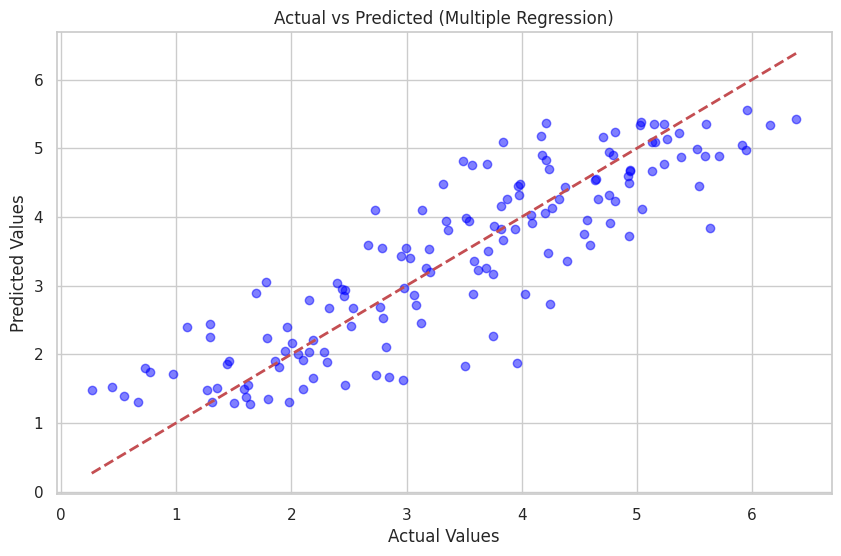

In [ ]:
income = pd.read_csv('content/income_happy.csv')

target = 'happiness'
x = income.drop(target, axis=1)
y = income[target]

linear(x,y)

Train set shape: (354, 12)
Test set shape: (152, 12)
Coefficients: [-1.13844848e-01  6.11702680e-02  5.41034650e-02  2.51751196e+00
 -2.22485023e+01  2.69841282e+00  4.83604728e-03 -1.53429538e+00
  2.98833255e-01 -1.14135806e-02 -9.88914626e-01 -5.86132851e-01]
Intercept: 49.885234663817236
[Multiple Regression Results]
MAE: 3.44
MSE: 20.88
RMSE: 4.57
MAPE: 0.17
R2 Score: 0.7722
------------------------------


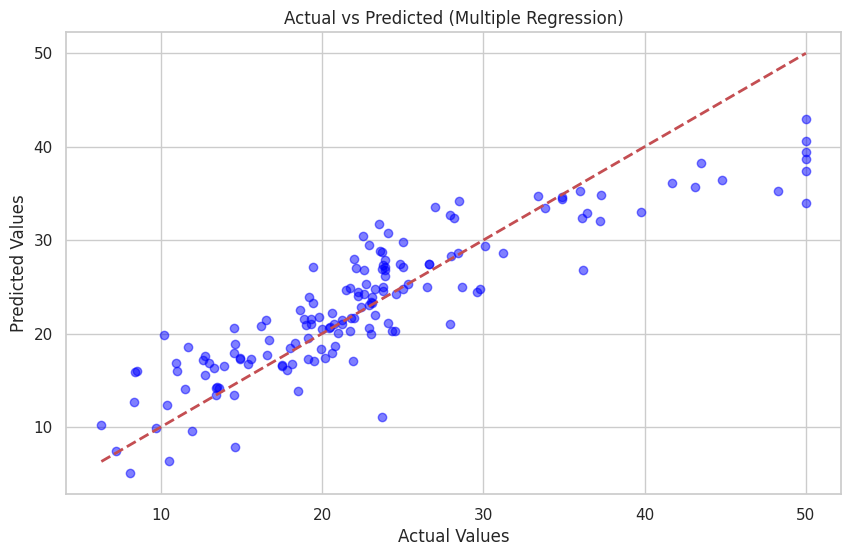

In [46]:
boston = pd.read_csv('content/boston.csv')

target = 'medv'
x = boston.drop([target], axis=1)
y = boston[target]

linear(x,y)

   GRE  TOEFL  RANK  SOP  LOR   GPA  RESEARCH  ADMIT
0  337    118     4  4.5  4.5  9.65         1      1
1  324    107     4  4.0  4.5  8.87         1      1
2  316    104     3  3.0  3.5  8.00         1      0
3  322    110     3  3.5  2.5  8.67         1      1
4  314    103     2  2.0  3.0  8.21         0      0
Train set shape: (350, 7)
Test set shape: (150, 7)


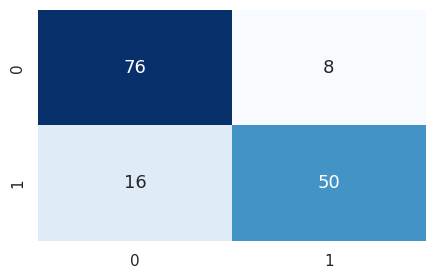

Accuracy :  0.84
Precision :  0.8620689655172413
Precision :  [0.82608696 0.86206897]
Precision :  0.8440779610194902
Precision :  0.8419190404797602
Recall :  0.7575757575757576
              precision    recall  f1-score   support

           0       0.83      0.90      0.86        84
           1       0.86      0.76      0.81        66

    accuracy                           0.84       150
   macro avg       0.84      0.83      0.84       150
weighted avg       0.84      0.84      0.84       150



In [113]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

adm = pd.read_csv('content/admission_simple.csv')

target = 'ADMIT'
x = adm.drop(target, axis=1)
y = adm[target]

print(adm.head())

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

print(f"Train set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

model = KNeighborsClassifier()

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))
sns.heatmap(cm,
            annot=True, 
            cbar=False,
            cmap='Blues',
            annot_kws={'size':13})
plt.show()

print('Accuracy : ', accuracy_score(y_test, y_pred))
print('Precision : ', precision_score(y_test,  y_pred))
print('Precision : ', precision_score(y_test,  y_pred, average=None))       # [0: 에 대한 pre, 1: 에 대한 pre]
print('Precision : ', precision_score(y_test,  y_pred, average='macro'))    # 각 클래스의 precision을 평균 내서 계산(산술 평균) 
print('Precision : ', precision_score(y_test,  y_pred, average='weighted')) # 각 클래스별로 가중치를 적용한 평균 -> 샘플 수가 많은 클래스에 더 높은 가중치를 부여
print('Recall : ', recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Train set shape: (623, 13)
Test set shape: (268, 13)


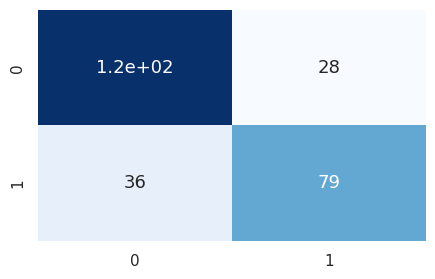

              precision    recall  f1-score   support

           0       0.78      0.82      0.80       153
           1       0.74      0.69      0.71       115

    accuracy                           0.76       268
   macro avg       0.76      0.75      0.75       268
weighted avg       0.76      0.76      0.76       268



In [ ]:
titanic = pd.read_csv('content/titanic_train.csv')

def extract_title(name):
    for title in ['Mr.', 'Mrs.', 'Miss.', 'Master']:
        if title in name:
            return title.replace('.', '')
    return 'Others'
titanic['Title'] = titanic['Name'].apply(extract_title)

remove = ['PassengerId', 'Name', 'Ticket', 'Cabin']

titanic.drop(remove, inplace=True, axis=1)

titanic['Age'] = titanic['Age'].fillna(titanic['Age'].groupby(by=titanic['Title']).transform('median'))

target = 'Survived'

x = titanic.drop(target, axis=1)
y = titanic[target]

x = pd.get_dummies(x, columns=['Sex', 'Embarked', 'Pclass', 'Title'], drop_first=True)

x.head()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

print(f"Train set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

model = KNeighborsClassifier()

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))
sns.heatmap(cm,
            annot=True, 
            cbar=False,
            cmap='Blues',
            annot_kws={'size':13})
plt.show()

print(classification_report(y_test, y_pred))

Train set shape: (105, 4)
Test set shape: (45, 4)


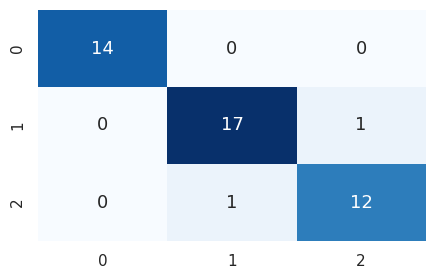

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.94      0.94      0.94        18
   virginica       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



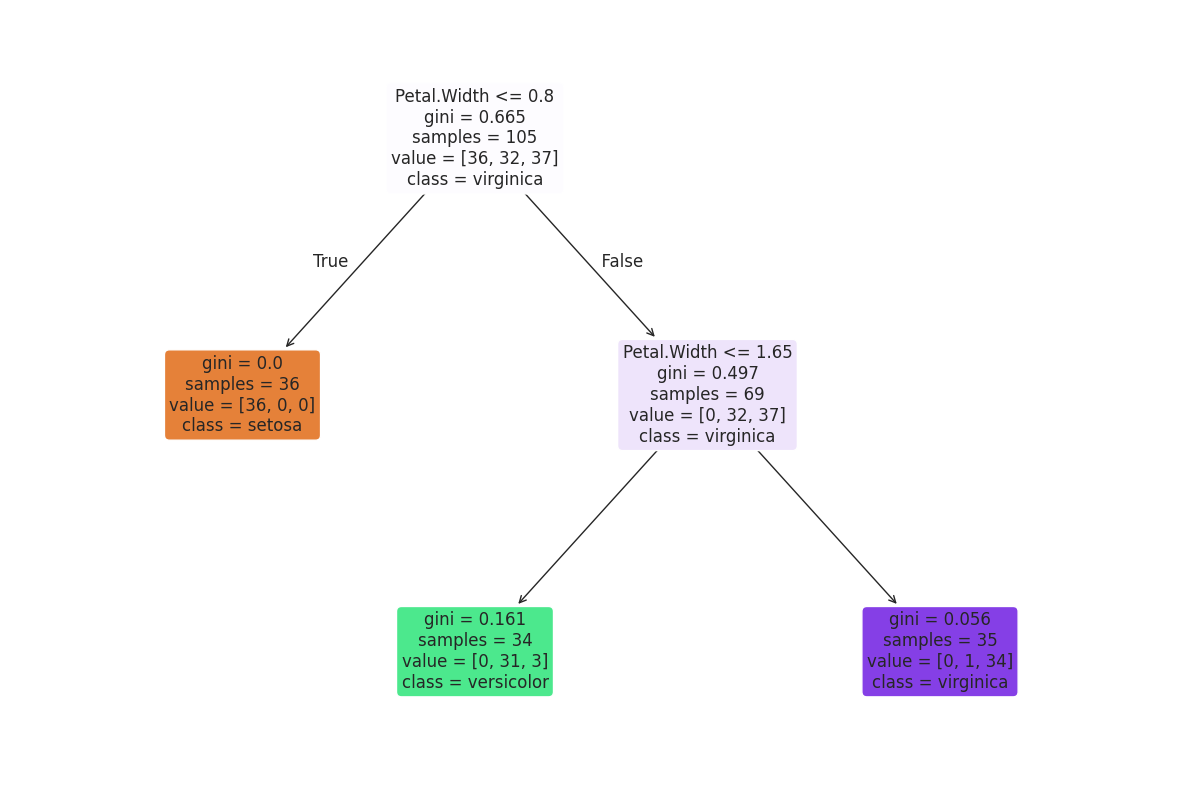

In [130]:
from sklearn.tree import plot_tree

iris = pd.read_csv('content/iris.csv')

target = 'Species'

x = iris.drop(target, axis=1)
y = iris[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

print(f"Train set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

model = DecisionTreeClassifier(max_depth=2, random_state=1)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))
sns.heatmap(cm,
            annot=True, 
            cbar=False,
            cmap='Blues',
            annot_kws={'size':13})
plt.show()

print(classification_report(y_test, y_pred))

# 그래프 크기 설정
plt.figure(figsize=(15, 10))
# 나무 그리기
plot_tree(model, 
          feature_names=x.columns,      # 변수 이름 (꽃받침 길이 등)
          class_names=model.classes_,   # 품종 이름 (Setosa 등)
          filled=True,                  # 색상 채우기 (다수결 클래스별로 색이 다름)
          rounded=True,                 # 박스 모서리 둥글게
          fontsize=12)                  # 글자 크기
plt.show()

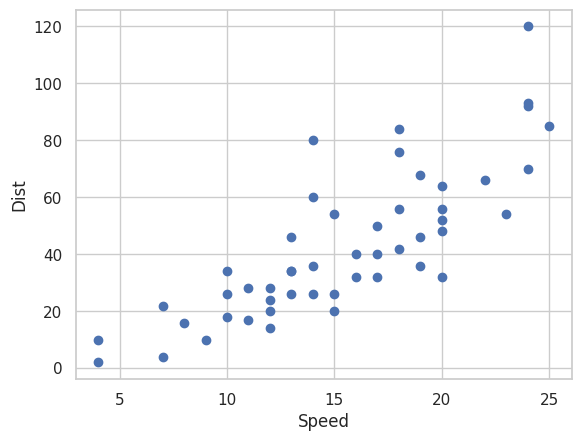

MAE : 12.101828348600227
R2 : 0.5640271559993144
가중치(기울기)  [4.05214656]
편향 (y절편)  -18.776238825736662


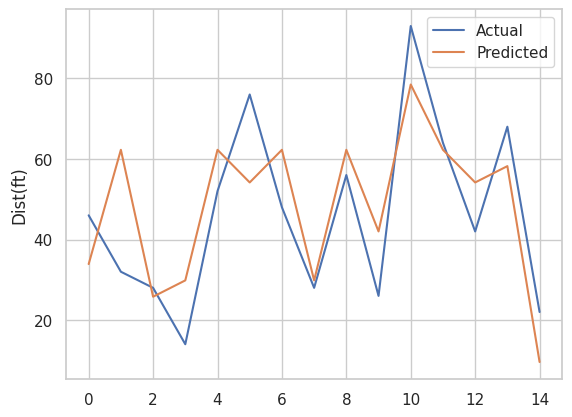

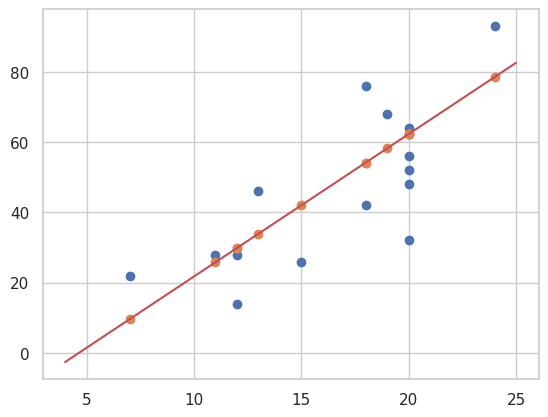

In [177]:
car = pd.read_csv('content/cars.csv')

plt.scatter(x='speed', y='dist', data=car)
plt.xlabel('Speed')
plt.ylabel('Dist')
plt.show()

target = 'dist'

X = car.drop(target, axis=1)
y = car[target]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=2026)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('MAE :', mean_absolute_error(y_test, y_pred))
print('R2 :', r2_score(y_test, y_pred))
print('가중치(기울기) ', model.coef_)      
print('편향 (y절편) ', model.intercept_) 

# 시각화
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.ylabel('Dist(ft)')
plt.show()

a = model.coef_     # 기울기(가중치)
b = model.intercept_ # 절편(상수항)

# 회귀선(직선)을 그리기 위한 x 구간 (최솟값~최댓값)
speed = np.array([X_train.min(), X_train.max()])
dist = a * speed + b        # 선형 회귀 공식

plt.scatter(X_test, y_test)         # 실제값
plt.scatter(X_test, y_pred)         # 예측값
plt.plot(speed, dist, color='r')    # 회귀선 - 빨간 직선으로 모델의 예측 패턴 표시
plt.show()

MAE : 0.5588237111283767
R2 : 0.7545536758581622
가중치(기울기)  [0.72244152]
편향 (y절편)  0.15849441169520473


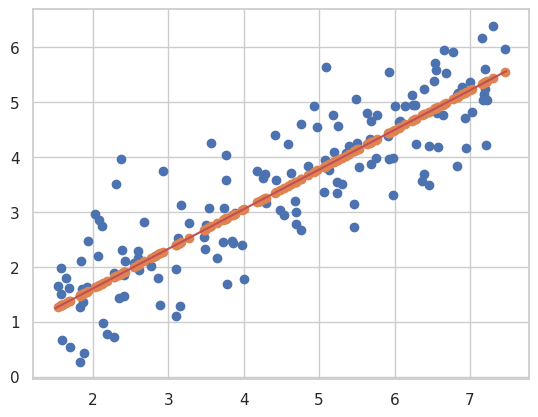

In [182]:
income = pd.read_csv('content/income_happy.csv')

income.corr()

target = 'happiness'

X = income.drop(target, axis=1)
y = income[target]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('MAE :', mean_absolute_error(y_test, y_pred))
print('R2 :', r2_score(y_test, y_pred))
print('가중치(기울기) ', model.coef_)      
print('편향 (y절편) ', model.intercept_) 

a = model.coef_     # 기울기(가중치)
b = model.intercept_ # 절편(상수항)

# 회귀선(직선)을 그리기 위한 x 구간 (최솟값~최댓값)
speed = np.array([X_train.min(), X_train.max()])
dist = a * speed + b        # 선형 회귀 공식

plt.scatter(X_test, y_test)         # 실제값
plt.scatter(X_test, y_pred)         # 예측값
plt.plot(speed, dist, color='r')    # 회귀선 - 빨간 직선으로 모델의 예측 패턴 표시
plt.show()

MAE : 0.841609880289612
R2 : 0.8657819916636769
가중치(기울기)  [ 9.42233545e-02  1.38354290e-02  1.29531548e-01 -5.23624544e-04
 -9.67176394e-02 -5.14878643e-02  4.85610255e+00  2.02857909e+00
 -2.75940270e-01 -2.24414376e-01 -2.15006864e-01 -1.29912858e-01
  1.22594171e-01 -3.67638446e-01 -3.34511218e-01 -3.84411744e-01
  1.78293080e-01 -2.41139115e-01]
편향 (y절편)  6.097879899078491


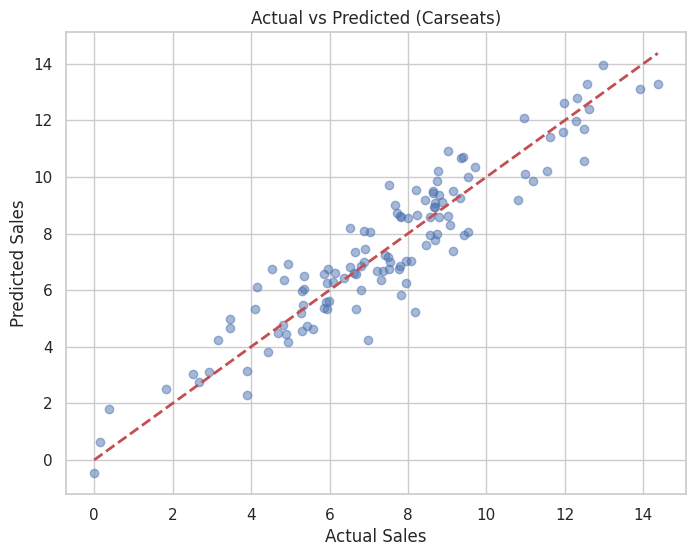

In [190]:
car = pd.read_csv('content/carseats.csv')

target = 'Sales'

X = pd.get_dummies(data=car.drop(target, axis=1), columns=['ShelveLoc', 'Education', 'Urban', 'US'], drop_first=True)
y = car[target]



X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('MAE :', mean_absolute_error(y_test, y_pred))
print('R2 :', r2_score(y_test, y_pred))
print('가중치(기울기) ', model.coef_)      
print('편향 (y절편) ', model.intercept_) 

# 1. 실제값 vs 예측값 산점도
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
# 2. 완벽한 예측을 의미하는 45도 직선 (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted (Carseats)')
plt.show()